In [1]:
!pip install -q datasets

In [2]:
!pip install -q ultralytics

In [3]:
!pip install cloudinary 

In [16]:
# Import required packages
import requests
from PIL import Image
from io import BytesIO
from ultralytics import YOLO

# Load the small YOLOv8 model (fastest)
model = YOLO("yolov8n.pt")  # nano model, fast


# Function to load image from HF URL
def load_image_from_url(url):
    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    img = Image.open(BytesIO(resp.content)).convert("RGB").resize((512, 512))
    return img


# Function to detect if only a person is present
def has_person(img):
    results = model(img)[0]

    # Convert detected class indices to class names
    classes = {model.names[int(c)] for c in results.boxes.cls}

    # Return True if "person" is present (even with other objects)
    # return "person" in classes
    return classes == {"person"}

In [92]:
from datasets import load_dataset

current_parquet = "train-00300-of-00571.parquet"

dataset = load_dataset(
    "parquet",
    data_files=f"https://huggingface.co/datasets/TIGER-Lab/OmniEdit-Filtered-1.2M/resolve/main/data/{current_parquet}",  # local path or HF URL
    split="train",
)

In [34]:
done_id = [
    "task_obj_swap_joint_mask_282321",
    "task_obj_swap_joint_mask_390369",
    "task_obj_swap_joint_mask_421842",
    "task_obj_swap_joint_mask_483143",
    "task_obj_swap_joint_mask_663269",
    "task_obj_swap_rand_mask_517630",
    "task_obj_swap_joint_mask_961135",
    "task_obj_swap_joint_mask_815591",
    "task_obj_swap_joint_mask_622149",
    "task_obj_swap_joint_mask_488886",
    "task_obj_swap_joint_mask_237760",
    "task_obj_swap_rand_mask_213276",
    "task_obj_swap_joint_mask_117135",
    "task_obj_swap_joint_mask_163191",
    "task_obj_swap_rand_mask_556922",
    "task_obj_swap_rand_mask_401875",
    "task_obj_swap_joint_mask_970754",
    "task_obj_swap_joint_mask_332832",
    "task_obj_swap_rand_mask_366951",
    "task_obj_swap_rand_mask_195790",
    "task_obj_swap_joint_mask_514258",
    "task_obj_swap_joint_mask_9695",
    "task_obj_swap_joint_mask_810125",
    "task_obj_swap_joint_mask_854899",
    "task_obj_swap_joint_mask_325583",
    "task_obj_swap_joint_mask_435497",
    "task_obj_swap_rand_mask_632148",
    "task_obj_swap_joint_mask_128048",
    "task_obj_swap_rand_mask_174173",
    "task_obj_swap_joint_mask_547534",
    "task_obj_swap_rand_mask_256901",
    "task_obj_swap_joint_mask_4824",
    "task_obj_swap_rand_mask_516190",
    "task_obj_swap_joint_mask_234295",
    "task_obj_swap_joint_mask_239354",
    "task_obj_swap_rand_mask_503246",
    "task_obj_swap_rand_mask_575297",
    "task_obj_swap_joint_mask_526840",
    "task_obj_swap_joint_mask_351289",
    "task_obj_swap_joint_mask_546281",
    "task_obj_swap_rand_mask_355501",
    "task_obj_swap_rand_mask_240577",
    "task_obj_swap_joint_mask_908891",
    "task_obj_swap_joint_mask_172397",
    "task_obj_swap_rand_mask_893066",
    "task_obj_swap_rand_mask_370995",
    "task_obj_swap_rand_mask_245962",
    "task_obj_swap_joint_mask_301501",
    "task_obj_swap_joint_mask_41000",
    "task_obj_swap_joint_mask_325195",
    "task_obj_swap_rand_mask_306724",
    "task_obj_swap_rand_mask_121485",
    "task_obj_swap_rand_mask_634764",
    "task_obj_swap_rand_mask_301907",
    "task_obj_swap_rand_mask_522421",
    "task_obj_swap_rand_mask_410887",
    "task_obj_swap_joint_mask_348661",
    "task_obj_swap_joint_mask_953046",
    "task_obj_swap_rand_mask_498228",
    "task_obj_swap_joint_mask_118029",
    "task_obj_swap_rand_mask_482732",
    "task_obj_swap_rand_mask_148291",
    "task_obj_swap_rand_mask_20402",
    "task_obj_swap_joint_mask_338090",
    "task_obj_swap_joint_mask_52466",
    "task_obj_swap_rand_mask_396615",
]

len(done_id)

66

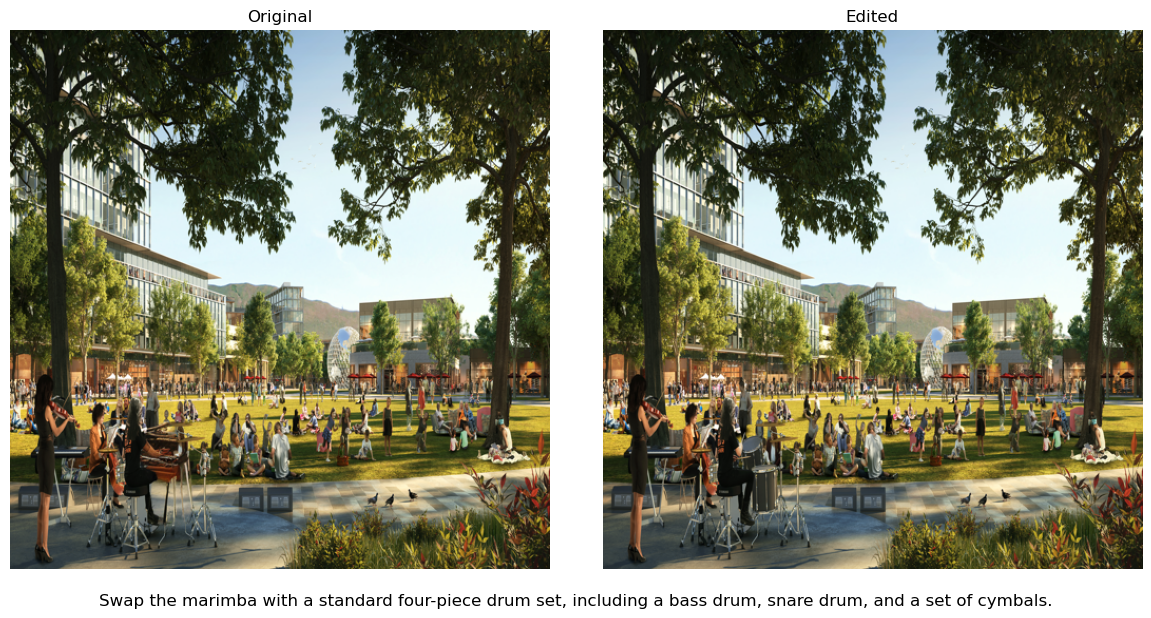

ID: task_obj_swap_rand_mask_488734  |  Task: swap
Has Person: True  |  Excluded Count: 101 | Included Count: 35
(Press Space/Enter to accept, 'n' + Enter to exclude, 'b' + Enter to break)


 b


In [37]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

excluded_id = []
last_id = None
accepted_id = []

for i, row in enumerate(dataset):
    img_id = row["omni_edit_id"]
    src_img = (row["src_img"]).resize((512, 512))
    edited_img = (row["edited_img"]).resize((512, 512))

    task = row["task"]
    prompt = row["edited_prompt_list"][-1]

    is_has_person = has_person(src_img)

    if not is_has_person or img_id in done_id:
        continue

    # clear previous outputs so screen doesn’t scroll
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # bottom prompt
    fig.text(0.5, 0.01, prompt, ha="center", va="bottom", fontsize=12, wrap=True)

    axes[0].imshow(src_img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(edited_img)
    axes[1].set_title("Edited")
    axes[1].axis("off")

    # leave space at bottom for prompt
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    print(f"ID: {img_id}  |  Task: {task}")
    print(
        f"Has Person: {is_has_person}  |  Excluded Count: {len(excluded_id)} | Included Count: {len(accepted_id)}"
    )
    print("(Press Space/Enter to accept, 'n' + Enter to exclude, 'b' + Enter to break)")

    ans = input().strip().lower()

    if ans == "n":
        excluded_id.append(img_id)
    elif ans == "b":
        break
    elif ans == "s":
        src_img.save("src_img.png")
        edited_img.save("edited_img.png")
    else:
        accepted_id.append(img_id)

    last_id = img_id

In [46]:
accepted_id

['task_obj_swap_joint_mask_413371',
 'task_obj_swap_joint_mask_433394',
 'task_obj_swap_rand_mask_411717',
 'task_obj_swap_rand_mask_571062',
 'task_obj_swap_joint_mask_73593',
 'task_obj_swap_joint_mask_882798',
 'task_obj_swap_rand_mask_718518',
 'task_obj_swap_joint_mask_465935',
 'task_obj_swap_joint_mask_786849',
 'task_obj_swap_rand_mask_249265',
 'task_obj_swap_joint_mask_438826',
 'task_obj_swap_joint_mask_88117',
 'task_obj_swap_rand_mask_340773',
 'task_obj_swap_rand_mask_421706',
 'task_obj_swap_joint_mask_528273',
 'task_obj_swap_joint_mask_542657',
 'task_obj_swap_rand_mask_123074',
 'task_obj_swap_rand_mask_525864',
 'task_obj_swap_rand_mask_223791',
 'task_obj_swap_rand_mask_178417',
 'task_obj_swap_joint_mask_299763',
 'task_obj_swap_joint_mask_775560',
 'task_obj_swap_joint_mask_164811',
 'task_obj_swap_joint_mask_857242',
 'task_obj_swap_joint_mask_451234',
 'task_obj_swap_rand_mask_197831',
 'task_obj_swap_rand_mask_84106',
 'task_obj_swap_joint_mask_323211',
 'task_

In [49]:
accepted_id = [
    "task_obj_swap_joint_mask_413371",
    "task_obj_swap_joint_mask_433394",
    "task_obj_swap_rand_mask_411717",
    "task_obj_swap_rand_mask_571062",
    "task_obj_swap_joint_mask_73593",
    "task_obj_swap_joint_mask_882798",
    "task_obj_swap_rand_mask_718518",
    "task_obj_swap_joint_mask_465935",
    "task_obj_swap_joint_mask_786849",
    "task_obj_swap_rand_mask_249265",
    "task_obj_swap_joint_mask_438826",
    "task_obj_swap_joint_mask_88117",
    "task_obj_swap_rand_mask_340773",
    "task_obj_swap_rand_mask_421706",
    "task_obj_swap_joint_mask_528273",
    "task_obj_swap_joint_mask_542657",
    "task_obj_swap_rand_mask_123074",
    "task_obj_swap_rand_mask_525864",
    "task_obj_swap_rand_mask_223791",
    "task_obj_swap_rand_mask_178417",
    "task_obj_swap_joint_mask_775560",
    "task_obj_swap_joint_mask_164811",
    "task_obj_swap_joint_mask_857242",
    "task_obj_swap_joint_mask_451234",
    "task_obj_swap_rand_mask_197831",
    "task_obj_swap_rand_mask_84106",
    "task_obj_swap_joint_mask_323211",
    "task_obj_swap_joint_mask_504710",
    "task_obj_swap_rand_mask_60955",
    "task_obj_swap_joint_mask_453534",
    "task_obj_swap_joint_mask_496778",
    "task_obj_swap_rand_mask_249766",
    "task_obj_swap_joint_mask_101218",
    "task_obj_swap_joint_mask_363532",
    "task_obj_swap_rand_mask_306724",
    "task_obj_swap_rand_mask_121485",
    "task_obj_swap_rand_mask_634764",
    "task_obj_swap_rand_mask_301907",
    "task_obj_swap_rand_mask_522421",
    "task_obj_swap_rand_mask_410887",
    "task_obj_swap_joint_mask_348661",
    "task_obj_swap_joint_mask_953046",
    "task_obj_swap_rand_mask_498228",
    "task_obj_swap_joint_mask_118029",
    "task_obj_swap_rand_mask_482732",
    "task_obj_swap_rand_mask_148291",
    "task_obj_swap_rand_mask_20402",
    "task_obj_swap_joint_mask_338090",
    "task_obj_swap_joint_mask_52466",
    "task_obj_swap_rand_mask_396615",
]

In [50]:
len(accepted_id)

50

In [60]:
import os, csv
from pathlib import Path

METADATA_FILE = "metadata/metadata.csv"
METADATA_FILE = Path(METADATA_FILE)
METADATA_FILE.parent.mkdir(parents=True, exist_ok=True)

def save_entry_and_log(src_img, edited_img, new_id, omni_edit_id, task, prompts, source):
    """
    Saves source and edited images using the new naming convention
    and logs metadata to CSV.
    Structure:
      - phase1a/orig/a_{num}_orig.png
      - phase1a/edited/a_{num}_edited.png
      - phase1a/metadata.csv
    """
    # 1. Define Subdirectories


    # 3. Save Images using new_id (e.g., a_001)
    src_filename = f"{new_id}_orig.png"
    edited_filename = f"{new_id}_edited.png"
    
    src_path = Path("phase1a/src/orig") / src_filename
    edited_path = Path("phase1a/src/edited") / edited_filename
    
    # Create parent directories only
    src_path.parent.mkdir(parents=True, exist_ok=True)
    edited_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Save images
    src_img.save(src_path)
    edited_img.save(edited_path)

    print(f"Saved: {src_filename} & {edited_filename}")

    # 4. Save Metadata to CSV
    prompt_str = prompts[-1] if isinstance(prompts, list) and prompts else str(prompts)

    row_data = {
        "img_id": new_id,
        "omni_edit_id": omni_edit_id,
        "editing_task": task,
        "edit_prompt": prompt_str
        "source": source
    }

    file_exists = os.path.isfile(METADATA_FILE)

    with open(METADATA_FILE, mode='a', newline='', encoding='utf-8') as csvfile:
        fieldnames = ["img_id", "omni_edit_id", "editing_task", "edit_prompt", "source"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()

        writer.writerow(row_data)

In [53]:
id_start = 100 + 1 + 50

remaining = set(accepted_id)

for i, row in enumerate(dataset):
    img_id = row["omni_edit_id"]

    # Skip rows not in accepted list
    if img_id not in remaining:
        continue

    # Process it
    src_img = (row["src_img"]).resize((512, 512))
    edited_img = (row["edited_img"]).resize((512, 512))

    task = row["task"]
    prompts = row["edited_prompt_list"]
    generated_id = f"a_{id_start:03d}"

    save_entry_and_log(
        src_img, edited_img, generated_id, img_id, task, prompts, current_parquet
    )

    # Remove it so we don't process it again
    remaining.remove(img_id)
    id_start += 1  # increment your counter

    # Stop early if done
    if not remaining:
        print("All accepted IDs processed — stopping early.")
        break

Saved: a_151_orig.png & a_151_edited.png
Saved: a_152_orig.png & a_152_edited.png
Saved: a_153_orig.png & a_153_edited.png
Saved: a_154_orig.png & a_154_edited.png
Saved: a_155_orig.png & a_155_edited.png
Saved: a_156_orig.png & a_156_edited.png
Saved: a_157_orig.png & a_157_edited.png
Saved: a_158_orig.png & a_158_edited.png
Saved: a_159_orig.png & a_159_edited.png
Saved: a_160_orig.png & a_160_edited.png
Saved: a_161_orig.png & a_161_edited.png
Saved: a_162_orig.png & a_162_edited.png
Saved: a_163_orig.png & a_163_edited.png
Saved: a_164_orig.png & a_164_edited.png
Saved: a_165_orig.png & a_165_edited.png
Saved: a_166_orig.png & a_166_edited.png
Saved: a_167_orig.png & a_167_edited.png
Saved: a_168_orig.png & a_168_edited.png
Saved: a_169_orig.png & a_169_edited.png
Saved: a_170_orig.png & a_170_edited.png
Saved: a_171_orig.png & a_171_edited.png
Saved: a_172_orig.png & a_172_edited.png
Saved: a_173_orig.png & a_173_edited.png
Saved: a_174_orig.png & a_174_edited.png
Saved: a_175_ori

In [64]:
from pathlib import Path
from typing import List
from concurrent.futures import ThreadPoolExecutor, as_completed


IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".gif",
    ".bmp",
    ".tiff",
    ".tif",
    ".webp",
    ".ico",
    ".heic",
}


def cloudinary_upload_one_file(
    local_root: Path,
    local_path: Path,
    cloudinary_folder: Path,
) -> str:
    """
    Upload a single file to Cloudinary, preserving subfolder structure.
    """
    # Make sure local_root and local_path are Path objects
    local_root = Path(local_root)
    local_path = Path(local_path)
    cloudinary_folder = Path(cloudinary_folder)

    # Relative path from the root, POSIX style (forward slashes)
    rel_dir = local_path.parent.relative_to(local_root).as_posix()

    dest_folder = (
        cloudinary_folder.as_posix()
        if rel_dir == "."
        else Path(cloudinary_folder, rel_dir).as_posix()
    )

    ext = local_path.suffix.lower()

    # check extension
    if ext in IMAGE_EXTENSIONS:
        upload_kwargs = {
            "folder": dest_folder,
            "use_filename": True,
            "unique_filename": False,
            # no resource_type => default is image
        }
    else:
        upload_kwargs = {
            "folder": dest_folder,
            "use_filename": True,
            "unique_filename": False,
            "resource_type": "auto",  # not an image
        }

    result = cloudinary.uploader.upload(str(local_path), **upload_kwargs)

    return result["url"]


def cloudinary_upload_folder(
    folder_path: str | Path,
    cloudinary_folder: str | Path,
    max_workers: int = 8,
) -> List[str]:
    """
    Recursively uploads all files in folder_path to Cloudinary in parallel.
    Returns the list of uploaded URLs.
    """
    folder_path = Path(folder_path)
    local_files: List[Path] = [p for p in folder_path.rglob("*") if p.is_file()]

    # print(local_files)

    uploaded_urls: List[str] = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(
                cloudinary_upload_one_file,
                folder_path,
                local_path,
                cloudinary_folder,
            ): local_path
            for local_path in local_files
        }

        for future in as_completed(futures):
            local_path = futures[future]
            try:
                url = future.result()
                uploaded_urls.append(url)
                print(url)
            except Exception as e:
                print(f"[UPLOAD FAILED] {local_path}: {e}")

    return uploaded_urls

In [78]:
import cloudinary
import cloudinary.uploader
import cloudinary.api
import yaml

with open("configs/secrets.yaml") as f:
    secrets_cfg = yaml.safe_load(f)

cloud_name = secrets_cfg["CLOUDINARY"]["CLOUD_NAME"]
api_key = secrets_cfg["CLOUDINARY"]["API_KEY"]
api_secret = secrets_cfg["CLOUDINARY"]["API_SECRET"]

cloudinary.config(
    cloud_name=cloud_name,
    api_key=api_key,
    api_secret=api_secret,
)

folder_to_upload = "phase1a"
upload_root = "research/dctroy/datasets/phase1a"

res = cloudinary_upload_folder(
    folder_to_upload,
    Path(upload_root),
)

http://res.cloudinary.com/dajw2wgld/image/upload/v1768741543/research/dctroy/datasets/phase1a/src/orig/a_006_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768741543/research/dctroy/datasets/phase1a/src/orig/a_007_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768741543/research/dctroy/datasets/phase1a/src/orig/a_005_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768741542/research/dctroy/datasets/phase1a/src/orig/a_003_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768804511/research/dctroy/datasets/phase1a/src/orig/a_001_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768804511/research/dctroy/datasets/phase1a/src/orig/a_002_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768741543/research/dctroy/datasets/phase1a/src/orig/a_008_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v1768741543/research/dctroy/datasets/phase1a/src/orig/a_011_orig.png
http://res.cloudinary.com/dajw2wgld/image/upload/v176874

In [1]:
%cd ..

c:\Users\HusPhil\Documents\fourth-year-cs\thesis\dctroy\project_dctroy


In [5]:
from utils.data_controller import cloudinary_download_folder
import os, cloudinary, yaml

with open("configs/secrets.yaml") as f:
    secrets_cfg = yaml.safe_load(f)

cloud_name = secrets_cfg["CLOUDINARY"]["CLOUD_NAME"]
api_key = secrets_cfg["CLOUDINARY"]["API_KEY"]
api_secret = secrets_cfg["CLOUDINARY"]["API_SECRET"]

cloudinary.config(
    cloud_name=cloud_name,
    api_key=api_key,
    api_secret=api_secret,
)


# --- USAGE ---
# Using an absolute path to be sure where files go
LOCAL_OUTPUT_FOLDER = os.path.abspath("./datasets/phase1a/src/orig")

CLOUD_FOLDER = "research/dctroy/datasets/phase1a/src/orig"
cloudinary_download_folder(CLOUD_FOLDER, LOCAL_OUTPUT_FOLDER)

# CLOUD_FOLDER = "research/dctroy/datasets/phase1a/src/edited"
# cloudinary_download_folder(CLOUD_FOLDER, LOCAL_OUTPUT_FOLDER)

1. Generating download URL for: research/dctroy/datasets/phase1a/src/orig
2. Downloading ZIP...
3. Extracting and flattening files...
Files extracted to: c:\Users\HusPhil\Documents\fourth-year-cs\thesis\dctroy\project_dctroy\datasets\phase1a\src\orig
4. Cleaning up temporary ZIP file...
